In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [6]:
final_df1 = pd.read_csv(
    "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/trend_by_year_and_product.csv",
    low_memory=False
)
print(f" {final_df.shape[0]:,}")
print(f" {final_df.columns.tolist()}")

 22,558
 ['product_code', 'YEAR', 'num_complaints', 'num_recalls']


In [7]:
print(f"Shape: {final_df.shape[0]:,} rows x {final_df.shape[1]} cols")
print(f"\nColumns: {final_df.columns.tolist()}")
print(f"\nDtypes:\n{final_df.dtypes}")
print(f"\nNull rates:\n{final_df.isnull().mean().mul(100).round(1).sort_values(ascending=False)}")
final_df.head(3).T

Shape: 22,558 rows x 4 cols

Columns: ['product_code', 'YEAR', 'num_complaints', 'num_recalls']

Dtypes:
product_code      object
YEAR               int64
num_complaints     int64
num_recalls        int64
dtype: object

Null rates:
product_code      0.0
YEAR              0.0
num_complaints    0.0
num_recalls       0.0
dtype: float64


,0,1,2
product_code,OCE,NBW,MQP
YEAR,2017,2015,2015
num_complaints,6,60955,258
num_recalls,0,0,0


In [8]:
# Aggregate across all products by year
yearly_trend = final_df.groupby('YEAR').agg(
    total_complaints=('num_complaints', 'sum'),
    total_recalls=('num_recalls', 'sum')
).reset_index()

print(yearly_trend)

    YEAR  total_complaints  total_recalls
0   2015            850782           2708
1   2016            858142           2772
2   2017            923493           2972
3   2018           1015866           2831
4   2019           1304779           2825
5   2020           1546454           2455
6   2021           1990330           2148
7   2022           2898205           2096
8   2023           2320212           2449
9   2024           2578656           3139
10  2025           2840787           2591


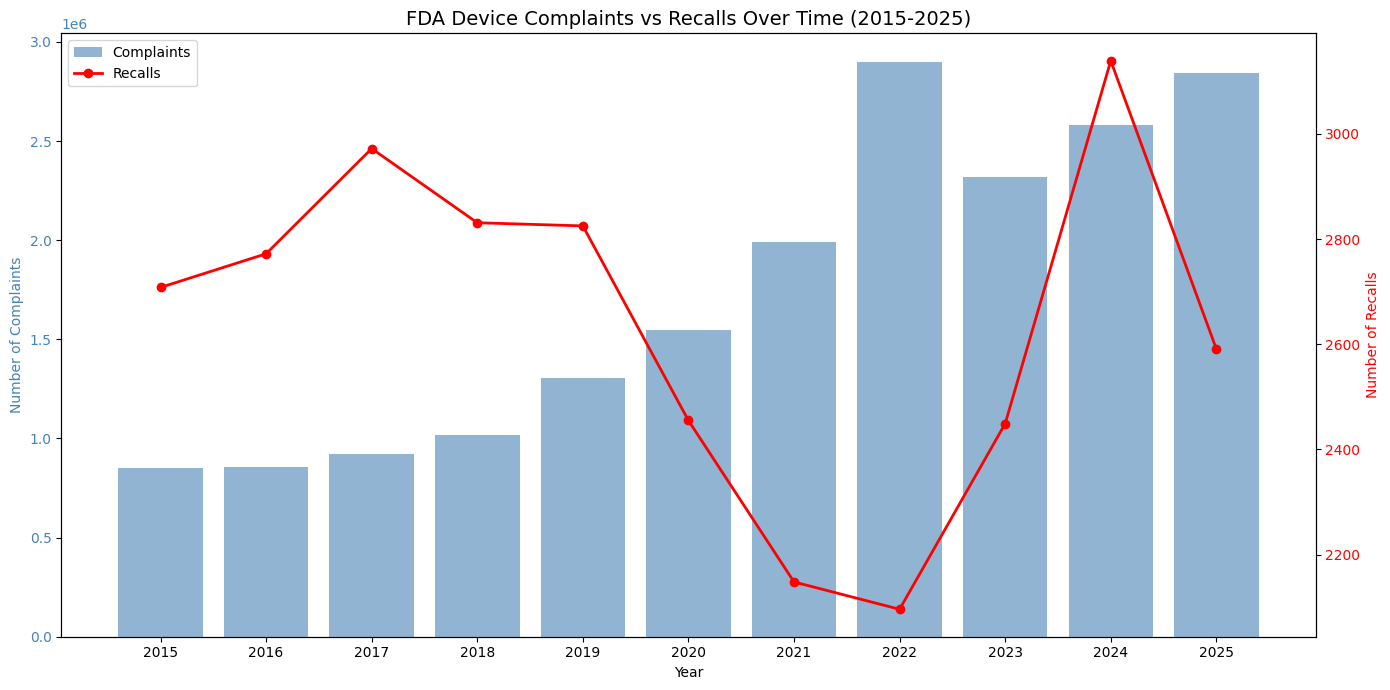

In [9]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(yearly_trend['YEAR'], yearly_trend['total_complaints'],
        color='steelblue', alpha=0.6, label='Complaints')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Complaints', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly_trend['YEAR'], yearly_trend['total_recalls'],
         color='red', marker='o', linewidth=2, label='Recalls')
ax2.set_ylabel('Number of Recalls', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('FDA Device Complaints vs Recalls Over Time (2015-2025)', fontsize=14)
plt.xticks(yearly_trend['YEAR'], rotation=45)
plt.tight_layout()
plt.savefig('complaints_vs_recalls_trend.png', dpi=150)
plt.show()

In [10]:
# Focus on products that have at least 1 recall
recalled_products = final_df[final_df['num_recalls'] > 0]

# For each product, find complaints in years BEFORE first recall
first_recall_year = recalled_products.groupby('product_code')['YEAR']\
    .min().reset_index()
first_recall_year.columns = ['product_code', 'first_recall_year']

# Join back
analysis_df = pd.merge(final_df, first_recall_year, on='product_code', how='inner')

# Complaints BEFORE recall year
complaints_before = analysis_df[analysis_df['YEAR'] < analysis_df['first_recall_year']]\
    .groupby('product_code')['num_complaints'].sum().reset_index()
complaints_before.columns = ['product_code', 'complaints_before_recall']

print(complaints_before['complaints_before_recall'].describe())
print(f"\nMedian complaints before recall: {complaints_before['complaints_before_recall'].median():,.0f}")
print(f"Mean complaints before recall: {complaints_before['complaints_before_recall'].mean():,.0f}")

count       958.000000
mean        879.508351
std        8523.890759
min           1.000000
25%           7.000000
50%          28.000000
75%         139.750000
max      218784.000000
Name: complaints_before_recall, dtype: float64

Median complaints before recall: 28
Mean complaints before recall: 880


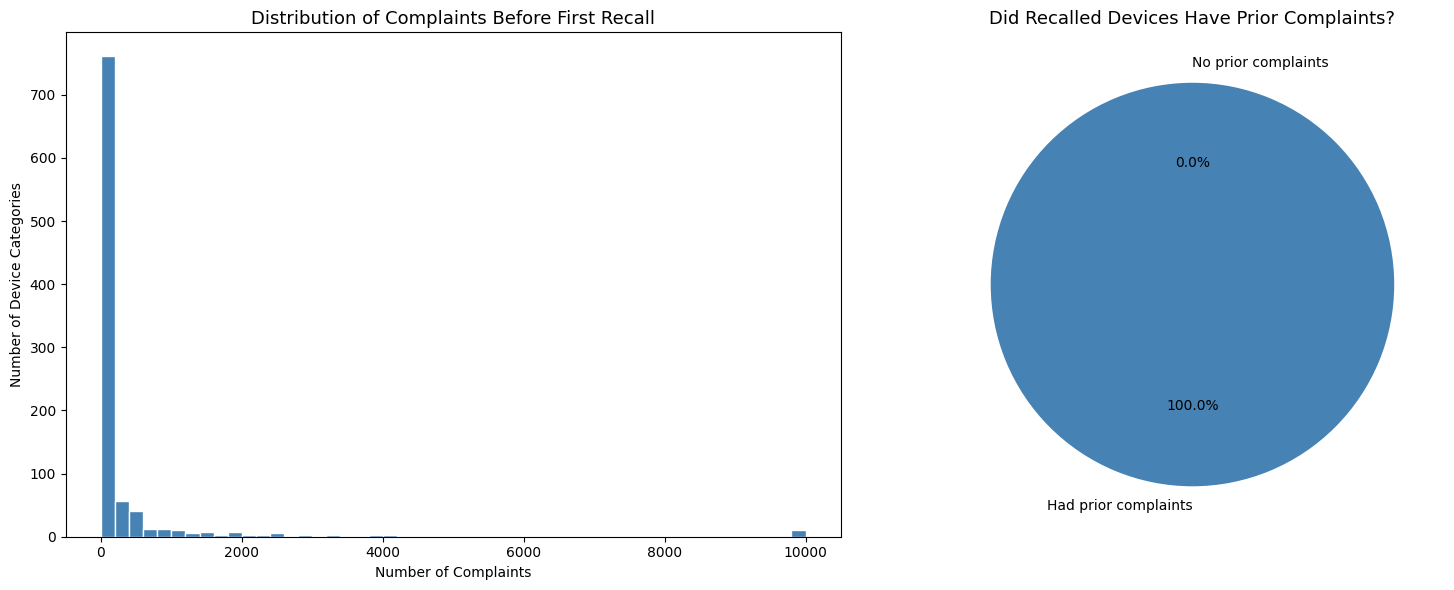

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution
axes[0].hist(complaints_before['complaints_before_recall'].clip(upper=10000), 
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Complaints Before First Recall', fontsize=13)
axes[0].set_xlabel('Number of Complaints')
axes[0].set_ylabel('Number of Device Categories')

# Products with 0 complaints before recall
zero_complaints = (complaints_before['complaints_before_recall'] == 0).sum()
has_complaints = (complaints_before['complaints_before_recall'] > 0).sum()

axes[1].pie([zero_complaints, has_complaints],
            labels=['No prior complaints', 'Had prior complaints'],
            colors=['salmon', 'steelblue'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Did Recalled Devices Have Prior Complaints?', fontsize=13)

plt.tight_layout()
plt.savefig('complaints_before_recall.png', dpi=150)
plt.show()

In [12]:
# Products with both complaints and recalls
both = final_df[(final_df['num_complaints'] > 0) & (final_df['num_recalls'] > 0)]

print(f"Products with BOTH complaints and recalls: {both['product_code'].nunique():,}")
print(f"Products with complaints only: {final_df[(final_df['num_complaints'] > 0) & (final_df['num_recalls'] == 0)]['product_code'].nunique():,}")
print(f"Products with recalls only: {final_df[(final_df['num_complaints'] == 0) & (final_df['num_recalls'] > 0)]['product_code'].nunique():,}")

# Ratio
both_agg = both.groupby('product_code').agg(
    total_complaints=('num_complaints', 'sum'),
    total_recalls=('num_recalls', 'sum')
).reset_index()
both_agg['complaints_per_recall'] = both_agg['total_complaints'] / both_agg['total_recalls']

print(f"\nAvg complaints per recall: {both_agg['complaints_per_recall'].mean():,.0f}")
print(f"Median complaints per recall: {both_agg['complaints_per_recall'].median():,.0f}")

Products with BOTH complaints and recalls: 1,571
Products with complaints only: 3,630
Products with recalls only: 0

Avg complaints per recall: 344
Median complaints per recall: 12


In [4]:
complaint_df = pd.read_csv(
    "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/d13.csv",
    low_memory=False
)
print(f"Complaint columns: {complaint_df.columns.tolist()}")

recall_df = pd.read_csv(
    "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/problem_recall_dataset.csv",
    low_memory=False
)
print(f"Recall columns: {recall_df.columns.tolist()}")

Complaint columns: ['MDR_REPORT_KEY', 'YEAR', 'FOI_TEXT', 'TEXT_LENGTH', 'BRAND_NAME', 'GENERIC_NAME', 'DEVICE_REPORT_PRODUCT_CODE', 'MANUFACTURER_D_NAME', 'DEVICE_SEQUENCE_NO', 'DATE_RECEIVED']
Recall columns: ['cfres_id', 'product_code', 'product_description', 'reason_for_recall', 'device_name', 'device_class', 'event_date_initiated', 'recall_status', 'similarity_score', 'FDA_CODE', 'problem_term', 'NCIT_CODE', 'IMDRF_CODE', 'FDA_mapped']


In [14]:
# Convert dates
complaint_df['DATE_RECEIVED'] = pd.to_datetime(complaint_df['DATE_RECEIVED'], errors='coerce')
recall_df['event_date_initiated'] = pd.to_datetime(recall_df['event_date_initiated'], errors='coerce')

# Extract year
complaint_df['COMPLAINT_YEAR'] = complaint_df['DATE_RECEIVED'].dt.year
recall_df['RECALL_YEAR'] = recall_df['event_date_initiated'].dt.year

print("Complaint date range:", complaint_df['DATE_RECEIVED'].min(), "→", complaint_df['DATE_RECEIVED'].max())
print("Recall date range:", recall_df['event_date_initiated'].min(), "→", recall_df['event_date_initiated'].max())

Complaint date range: 2015-01-01 00:00:00 → 2025-12-31 00:00:00
Recall date range: 1997-06-01 00:00:00 → 2026-02-06 00:00:00


In [15]:
# First complaint date per product code
first_complaint = complaint_df.groupby('DEVICE_REPORT_PRODUCT_CODE')['DATE_RECEIVED']\
    .min().reset_index()
first_complaint.columns = ['product_code', 'first_complaint_date']

# First recall date per product code
first_recall = recall_df.groupby('product_code')['event_date_initiated']\
    .min().reset_index()
first_recall.columns = ['product_code', 'first_recall_date']

# Join
timeline_df = pd.merge(first_complaint, first_recall, on='product_code', how='inner')

# Calculate time lag in days
timeline_df['time_lag_days'] = (
    timeline_df['first_recall_date'] - timeline_df['first_complaint_date']
).dt.days

print(f"Products with both complaints and recalls: {len(timeline_df):,}")
print(f"\nTime lag stats (days):")
print(timeline_df['time_lag_days'].describe())
print(f"\nMedian lag: {timeline_df['time_lag_days'].median():.0f} days")
print(f"Mean lag: {timeline_df['time_lag_days'].mean():.0f} days")

Products with both complaints and recalls: 2,226

Time lag stats (days):
count    2225.000000
mean    -1873.748764
std      2262.552475
min     -7929.000000
25%     -3815.000000
50%     -2178.000000
75%      -140.000000
max      3955.000000
Name: time_lag_days, dtype: float64

Median lag: -2178 days
Mean lag: -1874 days


In [16]:
def classify_timeline(days):
    if days < 0:
        return 'Recall Before Complaint'
    elif days <= 180:
        return 'Within 6 Months'
    elif days <= 365:
        return 'Within 1 Year'
    elif days <= 730:
        return 'Within 2 Years'
    else:
        return 'More Than 2 Years'

timeline_df['timeline_category'] = timeline_df['time_lag_days'].apply(classify_timeline)

print(timeline_df['timeline_category'].value_counts())
print(f"\nRecall BEFORE complaint: {(timeline_df['time_lag_days'] < 0).sum():,} ({(timeline_df['time_lag_days'] < 0).mean()*100:.1f}%)")
print(f"Complaint BEFORE recall: {(timeline_df['time_lag_days'] > 0).sum():,} ({(timeline_df['time_lag_days'] > 0).mean()*100:.1f}%)")

timeline_category
Recall Before Complaint    1716
More Than 2 Years           304
Within 2 Years               83
Within 6 Months              76
Within 1 Year                47
Name: count, dtype: int64

Recall BEFORE complaint: 1,716 (77.1%)
Complaint BEFORE recall: 509 (22.9%)


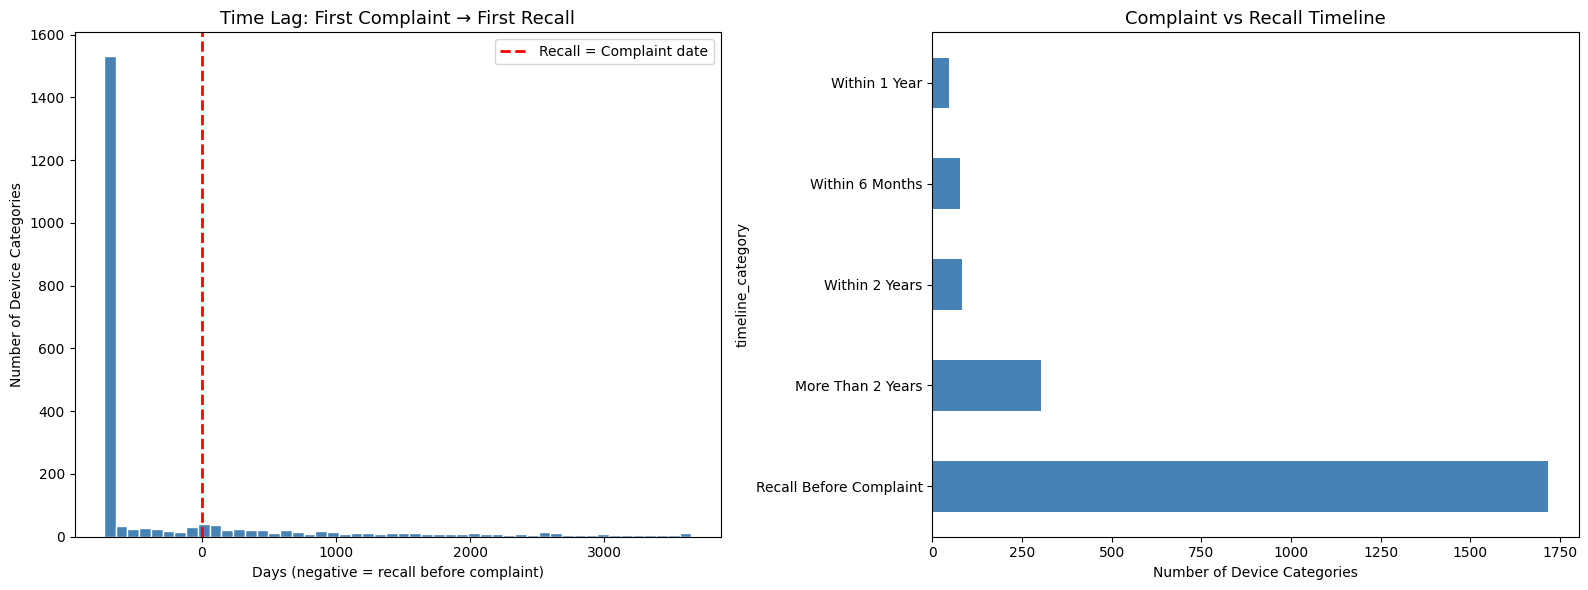

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Time lag distribution
axes[0].hist(timeline_df['time_lag_days'].clip(-730, 3650),
             bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Recall = Complaint date')
axes[0].set_title('Time Lag: First Complaint → First Recall', fontsize=13)
axes[0].set_xlabel('Days (negative = recall before complaint)')
axes[0].set_ylabel('Number of Device Categories')
axes[0].legend()

# Timeline category
timeline_df['timeline_category'].value_counts().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Complaint vs Recall Timeline', fontsize=13)
axes[1].set_xlabel('Number of Device Categories')

plt.tight_layout()
plt.show()

In [18]:
# Aggregate by year
complaint_trend = complaint_df.groupby('COMPLAINT_YEAR').size()\
    .reset_index(name='total_complaints')
complaint_trend = complaint_trend[complaint_trend['COMPLAINT_YEAR'].between(2015, 2025)]

recall_trend = recall_df.groupby('RECALL_YEAR').size()\
    .reset_index(name='total_recalls')
recall_trend = recall_trend[recall_trend['RECALL_YEAR'].between(2015, 2025)]

# Merge
trend_df = pd.merge(complaint_trend, recall_trend,
                    left_on='COMPLAINT_YEAR', right_on='RECALL_YEAR', how='outer')
trend_df['YEAR'] = trend_df['COMPLAINT_YEAR'].fillna(trend_df['RECALL_YEAR'])
trend_df = trend_df.sort_values('YEAR')

print(trend_df[['YEAR', 'total_complaints', 'total_recalls']])

      YEAR  total_complaints  total_recalls
0   2015.0            850782           2905
1   2016.0            858142           3029
2   2017.0            923493           3313
3   2018.0           1015870           3013
4   2019.0           1304790           3010
5   2020.0           1546460           2602
6   2021.0           1990334           2260
7   2022.0           2898229           2276
8   2023.0           2320300           2601
9   2024.0           2578695           3275
10  2025.0           2840808           2789
